# Module 03: EDA

In [120]:
# packages
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from sklearn.model_selection import train_test_split 
from ISLP import load_data

# set seed
seed = 2323

### We'll use the _Hitters_ data from ISLP for this activity. The metadata for _Hitters_ can be found [here](https://intro-stat-learning.github.io/ISLP/datasets/Hitters.html).

In [121]:
# Load the data
Hitters = load_data('Hitters')

### Determine the number of rows and columns in the dataset by returning its "shape" attribute

In [122]:
#fillin
Hitters.shape

(322, 20)

### Determine whether each feature is numeric or categorical by returning the "dtype" attribute for each column

In [123]:
Hitters.dtypes

AtBat           int64
Hits            int64
HmRun           int64
Runs            int64
RBI             int64
Walks           int64
Years           int64
CAtBat          int64
CHits           int64
CHmRun          int64
CRuns           int64
CRBI            int64
CWalks          int64
League       category
Division     category
PutOuts         int64
Assists         int64
Errors          int64
Salary        float64
NewLeague    category
dtype: object

### Before doing any other analyses, let's create training and test sets.

In [124]:
Train, Test = train_test_split(Hitters, 
                               random_state=seed, 
                               test_size=0.40, 
                               shuffle=True) 

### Based on the metadata, what is the difference between the 6 columns starting with 'C' and the 6 related columns that don't?

The columns without c are for specifically the 1986 season, while all columns with a c are for the batter's career

### On the training set, create pairwise scatterplots for each of these 6 columns with the 'Salary' variable.

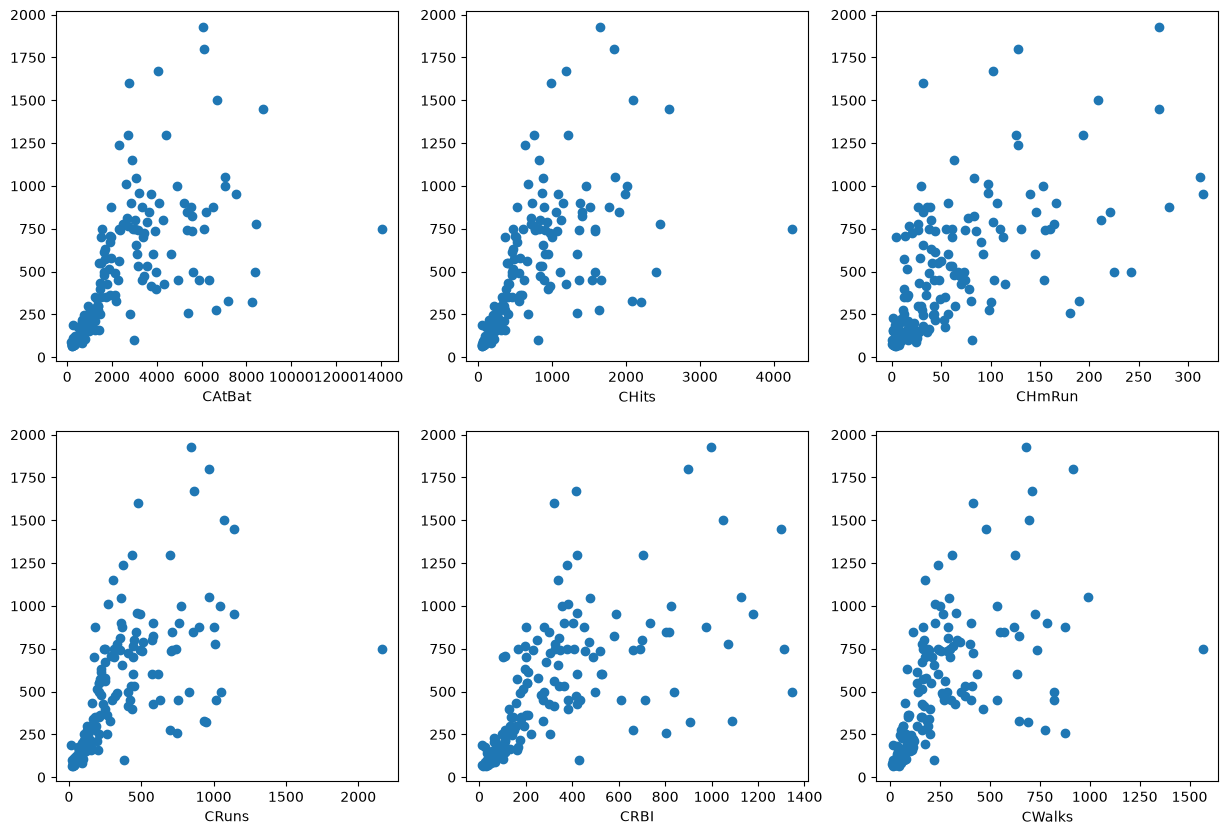

In [125]:
# First create a subset of the columns that we want to plot

subset = Train[['CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks']]

# Initialize the plots before drawing them

fig, axes = subplots(nrows=2,
                     ncols=3,
                     figsize=(15, 10))
# Copy the helper function

def range_to_grid(i,Ncol):
    x=[]
    y=[]
    for n in range(Ncol**2):
        x.append(int(np.floor(n/Ncol)))
        y.append(n % Ncol)
        #print(n,x[n],y[n])
    return x[i],y[i]

# Plot the variables

for j in range(len(subset.columns)):
    axes[range_to_grid(j,3)[0],range_to_grid(j,3)[1]].plot(subset.iloc[:,j], Train['Salary'], 'o')
    axes[range_to_grid(j,3)[0],range_to_grid(j,3)[1]].set_xlabel(subset.columns[j])


### Use the "describe" method to determine the mean, standard deviation, and 5 number summary of all numeric variables in the training subset of _Hitters_.

In [126]:
#fillin
for col in Hitters.columns:
    print(Hitters[col].describe())

count    322.000000
mean     380.928571
std      153.404981
min       16.000000
25%      255.250000
50%      379.500000
75%      512.000000
max      687.000000
Name: AtBat, dtype: float64
count    322.000000
mean     101.024845
std       46.454741
min        1.000000
25%       64.000000
50%       96.000000
75%      137.000000
max      238.000000
Name: Hits, dtype: float64
count    322.000000
mean      10.770186
std        8.709037
min        0.000000
25%        4.000000
50%        8.000000
75%       16.000000
max       40.000000
Name: HmRun, dtype: float64
count    322.000000
mean      50.909938
std       26.024095
min        0.000000
25%       30.250000
50%       48.000000
75%       69.000000
max      130.000000
Name: Runs, dtype: float64
count    322.000000
mean      48.027950
std       26.166895
min        0.000000
25%       28.000000
50%       44.000000
75%       64.750000
max      121.000000
Name: RBI, dtype: float64
count    322.000000
mean      38.742236
std       21.639327
min 

### It looks like the mean and median of 'AtBat' are nearly equal. This _might_ suggest that this variable is normally distributed. Create a histogram of 'AtBat' to check this hypothesis.

<Axes: >

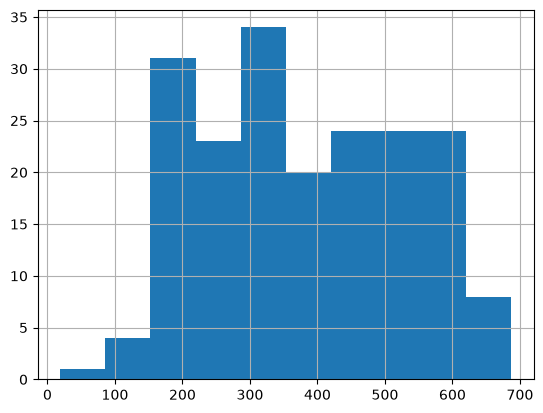

In [127]:
#fillin
Train["AtBat"].hist()


### Let's standardize the AtBat feature (i.e., normalize by z-scores). We'll create a new column in the training data called 'AtBat_st' to represent this.

In [128]:
#fillin
Train["AtBat_st"] = ((Train["AtBat"] - Train["AtBat"].mean()) / Train["AtBat"].std())
Train["AtBat_st"]

3      0.783715
63    -1.138317
27     0.632698
130   -0.520521
93     0.886681
         ...   
308    0.673885
90    -0.465605
147    1.490748
232   -0.472470
72     0.893546
Name: AtBat_st, Length: 193, dtype: float64

### How many rows have an 'AtBat' value within the first standard deviation?

Hint: the 'len' magic method returns the number of rows of a dataFrame.

In [129]:
#fillin
total = 0
for player in Train["AtBat_st"]:
    total += player > -1 and player < 1
total

115

### Going back to the results of the 'describe' method, how can you tell that the 'Salary' variable has missing values?

We can tell this because the count of Salary is only 263 while the count for the rest of the variables is 322. 

### Describe a situation where a variable could have missing values but this would not be reflected in the results of the 'describe' method.

If the mising values has a default rather than simply being empty. For example if every missing entry is -1 and every actual entry is a whole number. 

### On the training data, create separate boxplots of the 'AtBat' variable for when 'Salary' is populated or missing.

<Axes: title={'center': 'AtBat'}, xlabel='SalPop'>

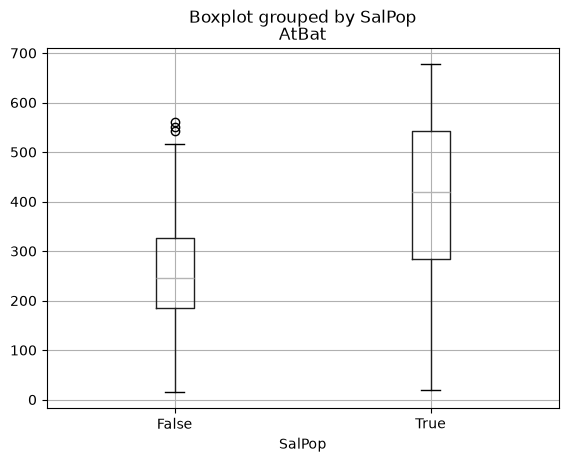

In [130]:
#fillin
SalSub = Test
SalSub["SalPop"] = Test["Salary"].notna()
# True means Salary is listed, False means salary is not listed
SalSub.boxplot(column="AtBat", by="SalPop")


### Create a correlation matrix for all numeric features in the training set

In [131]:
#fillin
Train.corr(numeric_only=True)

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,AtBat_st
AtBat,1.000000,0.963324,0.540323,0.906579,0.798717,0.631824,-0.039232,0.126602,0.146763,0.150166,0.164892,0.145779,0.056578,0.345879,0.363085,0.368162,0.401390,1.000000
Hits,0.963324,1.000000,0.516853,0.914739,0.795316,0.605876,-0.028717,0.133316,0.163329,0.136865,0.175542,0.153011,0.065178,0.312858,0.310422,0.301725,0.432558,0.963324
HmRun,0.540323,0.516853,1.000000,0.618439,0.840613,0.385425,0.009072,0.078981,0.076914,0.411917,0.110767,0.218285,0.080296,0.222084,-0.069088,0.062840,0.326021,0.540323
Runs,0.906579,0.914739,0.618439,1.000000,0.786635,0.711346,-0.069584,0.083770,0.103859,0.160979,0.159683,0.115628,0.099025,0.289952,0.184714,0.217297,0.441499,0.906579
RBI,0.798717,0.795316,0.840613,0.786635,1.000000,0.553527,0.046705,0.165837,0.180526,0.375072,0.191452,0.285074,0.117109,0.323825,0.138896,0.217983,0.414623,0.798717
Walks,0.631824,0.605876,0.385425,0.711346,0.553527,1.000000,0.037943,0.137157,0.147019,0.194766,0.205250,0.167453,0.312812,0.317000,0.139008,0.160753,0.458462,0.631824
Years,-0.039232,-0.028717,0.009072,-0.069584,0.046705,0.037943,1.000000,0.925308,0.906857,0.730478,0.882559,0.882835,0.836809,0.071301,-0.091915,-0.160476,0.541390,-0.039232
CAtBat,0.126602,0.133316,0.078981,0.083770,0.165837,0.137157,0.925308,1.000000,0.995185,0.775167,0.979705,0.948617,0.894573,0.120875,-0.000507,-0.068187,0.616677,0.126602
CHits,0.146763,0.163329,0.076914,0.103859,0.180526,0.147019,0.906857,0.995185,1.000000,0.761920,0.983128,0.945002,0.883547,0.132818,-0.003372,-0.062669,0.629875,0.146763
CHmRun,0.150166,0.136865,0.411917,0.160979,0.375072,0.194766,0.730478,0.775167,0.761920,1.000000,0.782490,0.912134,0.750795,0.126756,-0.129640,-0.141514,0.616170,0.150166


### Propose two different ways of imputing the missing values of Salary while taking advantage of the information given in the boxplots or the correlation matrix.

Salary has strong positive correlation with almost every other variable, because of this one way would be to estimate a salary using coeficents on every other variable to input the missing values. Another way is to just use the variables salary is most strongly correlated with, in this case we could use CAtBat, CHits, CHmRun, CRuns, and CRBI which all have a correlation of at least .6.	

### For our last exercise, we'll explore Hits and Walks relative to AtBat totals. 
- Use the sum function to calculuate the totals of each of these three variables for the 1986 season (on the training set). 
- Create a pie chart which shows total hits, total walks, and remaining total (neither) as percents of the At Bats total (on the training set). 

In [132]:
TotHits = Train["Hits"].sum()
TotWalks = Train["Walks"].sum()
TotAtBat = Train["AtBat"].sum()

Labels = ['Hits', 'Walks', 'Neither']
Totals = [TotHits, TotWalks, TotAtBat-TotHits-TotWalks]

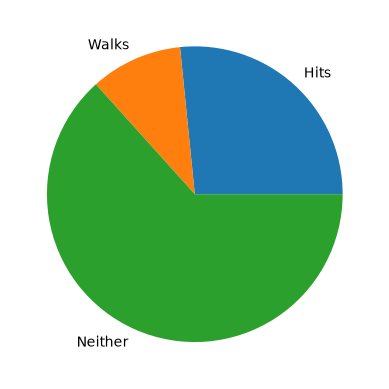

In [133]:
# pie chart
fig, ax = subplots()
ax.pie(Totals, labels=Labels)


### The previous two cells gave us totals across all players. For each player in the training set, calculate the Hits as a percent of AtBat and store it in a new variable called 'AVG'

In [134]:
#fillin
Train["AVG"] = Train["Hits"] / Train["AtBat"]
Train["AVG"] < .25

3      False
63      True
27     False
130    False
93     False
       ...  
308     True
90     False
147    False
232    False
72     False
Name: AVG, Length: 193, dtype: bool

### Using 0.25 and 0.31 as the split points, create a new variable with three bins: high, medium, and low. 

In [135]:
Train['AVG_bin'] = 'medium'
# This way kept throwing warnings and saying to use .loc
# Train['AVG_bin'][Train["AVG"] < .25] = 'low'
# Train['AVG_bin'][Train["AVG"] > .31] = 'high'
Train.loc[Train["AVG"] < .25, ["AVG_bin"]]= 'low'
Train.loc[Train["AVG"] > .31, ["AVG_bin"]]= 'high'
Train["AVG_bin"]

3      medium
63        low
27     medium
130      high
93     medium
        ...  
308       low
90     medium
147    medium
232    medium
72     medium
Name: AVG_bin, Length: 193, dtype: str

### Create a bar chart that displays the number of players in each of the low, medium, and high categories (for the training data).

<BarContainer object of 3 artists>

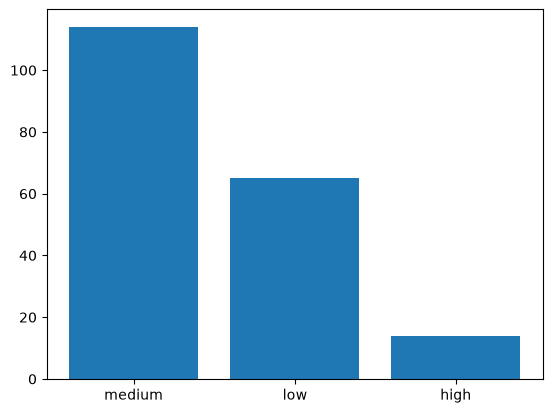

In [136]:
Train['AVG_bin'].value_counts()
plt.bar(Train["AVG_bin"].unique(), Train['AVG_bin'].value_counts())

Notice that the order of the bars will be medium, low, high. That's counterintuitive. We can reorder these quickly. 

In [137]:
indexMap = ['low', 'medium', 'high']
reordered_list = [Train['AVG_bin'].value_counts()[i] for i in indexMap]

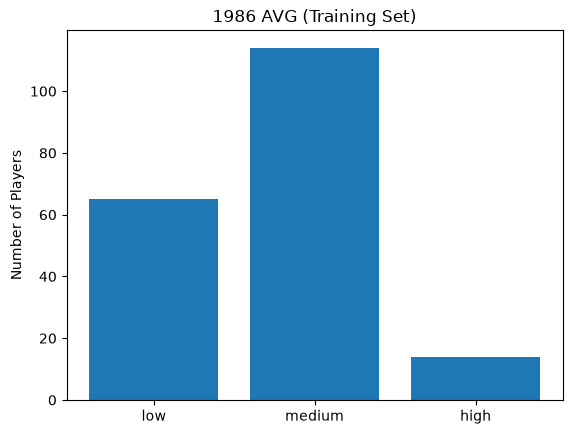

In [138]:
plt.bar(indexMap, reordered_list)

plt.title("1986 AVG (Training Set)")
plt.ylabel("Number of Players")

plt.xticks(indexMap)

plt.show()

### Did we use the depth method or width method for creating these bins? Explain.

We used the width method because the bins have wildly different numbers of entries per bin, so it can't have been depth.